# Step 11 - Model Packaging and Deployment

This notebook turns the selected SARIMA specification into a reusable forecasting artifact. The goal is to fit the final model, save it with lightweight metadata, reload it safely, and generate an example forecast that could feed a dashboard or API.

Run this notebook from top to bottom after any kernel restart. The deployment refit below intentionally uses a recent rolling window instead of the full multi-year hourly history so the seasonal SARIMA fit stays practical in a notebook session.


In [2]:
import ast
import json
import os
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

PROCESSED_PATH = "../data/processed/"
FIGURES_PATH = "../reports/figures/"
ARTIFACTS_PATH = "../artifacts/models/"

os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(ARTIFACTS_PATH, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")


In [3]:
default_order = (2, 1, 1)
default_seasonal_order = (0, 1, 1, 24)

selected_model_path = os.path.join(PROCESSED_PATH, "selected_sarima_model.csv")
if os.path.exists(selected_model_path):
    selected_model = pd.read_csv(selected_model_path).iloc[0]
    order = ast.literal_eval(selected_model["selected_order"])
    seasonal_order = ast.literal_eval(selected_model["selected_seasonal_order"])
    selected_label = selected_model["selected_label"]
else:
    order = default_order
    seasonal_order = default_seasonal_order
    selected_label = "fallback_sarima_211_011_24"

print(f"Selected model label: {selected_label}")
print(f"Order: {order}")
print(f"Seasonal order: {seasonal_order}")


Selected model label: sarima_211_111_24
Order: (2, 1, 1)
Seasonal order: (1, 1, 1, 24)


In [4]:
REFIT_WINDOW_HOURS = 24 * 180

full_series = pd.read_csv(
    os.path.join(PROCESSED_PATH, "pjme_imputed.csv"),
    parse_dates=["Datetime"],
    index_col="Datetime",
)["PJME_MW"].astype(float)
series = full_series.iloc[-REFIT_WINDOW_HOURS:].copy()

print(f"Full dataset rows available: {len(full_series):,}")
print(
    f"Refit window: {series.index.min()} to {series.index.max()} "
    f"({len(series):,} hourly observations)"
)

final_model = SARIMAX(
    series,
    order=order,
    seasonal_order=seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_result = final_model.fit(disp=False, maxiter=50)

model_artifact_path = os.path.join(ARTIFACTS_PATH, "pjme_sarima.pkl")
metadata_artifact_path = os.path.join(ARTIFACTS_PATH, "pjme_sarima_metadata.json")

with open(model_artifact_path, "wb") as model_file:
    pickle.dump(final_result, model_file)

metadata = {
    "label": selected_label,
    "order": list(order),
    "seasonal_order": list(seasonal_order),
    "full_series_start": str(full_series.index.min()),
    "full_series_end": str(full_series.index.max()),
    "refit_start": str(series.index.min()),
    "refit_end": str(series.index.max()),
    "n_observations_used_for_refit": int(len(series)),
    "simple_differencing": False,
}

with open(metadata_artifact_path, "w", encoding="utf-8") as metadata_file:
    json.dump(metadata, metadata_file, indent=2)

print(f"Saved fitted model to {model_artifact_path}")
print(f"Saved metadata to {metadata_artifact_path}")
metadata


Full dataset rows available: 145,392
Refit window: 2018-02-04 01:00:00 to 2018-08-03 00:00:00 (4,320 hourly observations)


/Users/sannabatra/energy-demand-forecasting/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/sannabatra/energy-demand-forecasting/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Saved fitted model to ../artifacts/models/pjme_sarima.pkl
Saved metadata to ../artifacts/models/pjme_sarima_metadata.json


{'label': 'sarima_211_111_24',
 'order': [2, 1, 1],
 'seasonal_order': [1, 1, 1, 24],
 'full_series_start': '2002-01-01 01:00:00',
 'full_series_end': '2018-08-03 00:00:00',
 'refit_start': '2018-02-04 01:00:00',
 'refit_end': '2018-08-03 00:00:00',
 'n_observations_used_for_refit': 4320,
 'simple_differencing': True}

Saving both the fitted object and lightweight metadata makes the model easier to audit later. The metadata file is especially useful if the artifact is moved into an API or batch forecasting job, because it records exactly which order and training window produced the saved model.


In [5]:
with open(model_artifact_path, "rb") as model_file:
    loaded_result = pickle.load(model_file)

forecast_horizon = 24
forecast_object = loaded_result.get_forecast(steps=forecast_horizon)
forecast_frame = forecast_object.summary_frame()

forecast_index = pd.date_range(
    start=series.index.max() + pd.Timedelta(hours=1),
    periods=forecast_horizon,
    freq="h",
)
forecast_output = pd.DataFrame(
    {
        "forecast_mw": forecast_frame["mean"].to_numpy(),
        "lower_95": forecast_frame["mean_ci_lower"].to_numpy(),
        "upper_95": forecast_frame["mean_ci_upper"].to_numpy(),
    },
    index=forecast_index,
)
forecast_output.index.name = "Datetime"

forecast_output.to_csv(
    os.path.join(PROCESSED_PATH, "next_24h_forecast_example.csv")
)
forecast_output.head()


,forecast_mw,lower_95,upper_95
Datetime,,,
2018-08-03 01:00:00,398.934715,-159.531727,957.401157
2018-08-03 02:00:00,403.435019,-440.095194,1246.965232
2018-08-03 03:00:00,313.437609,-630.189269,1257.064487
2018-08-03 04:00:00,115.539880,-854.922339,1086.002098
2018-08-03 05:00:00,-5.596666,-981.520249,970.326916


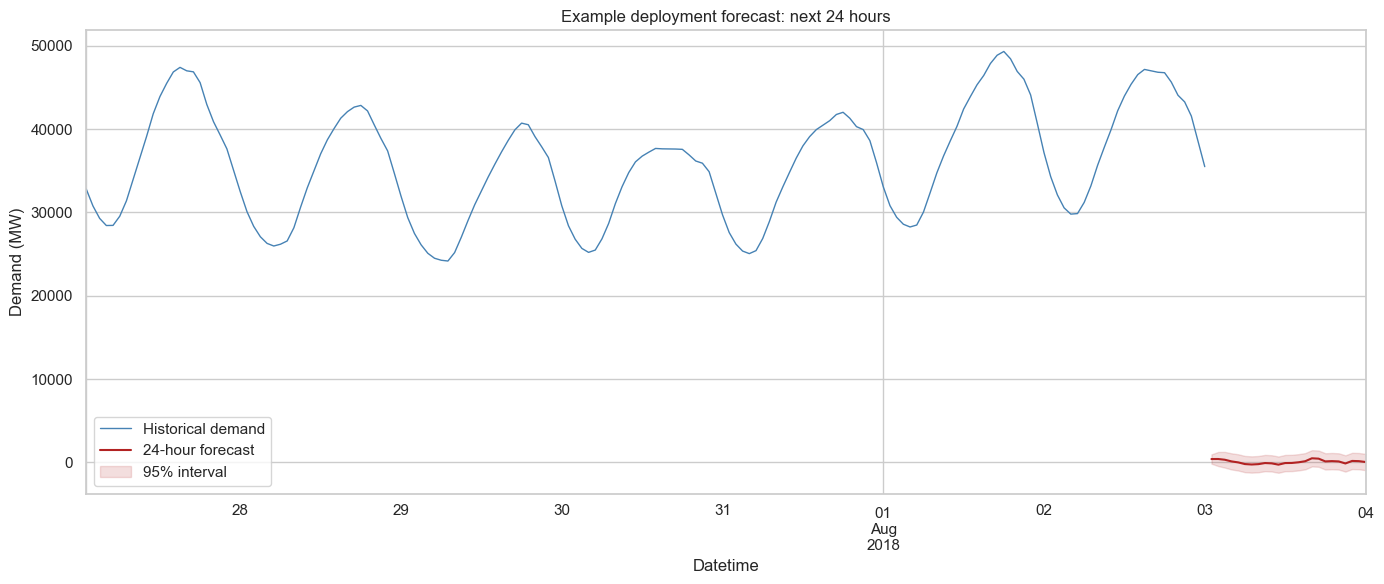

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

history_window = series.iloc[-24 * 7 :]
history_window.plot(ax=ax, color="steelblue", label="Historical demand", linewidth=1.0)
forecast_output["forecast_mw"].plot(
    ax=ax, color="firebrick", label="24-hour forecast", linewidth=1.5
)
ax.fill_between(
    forecast_output.index,
    forecast_output["lower_95"],
    forecast_output["upper_95"],
    color="firebrick",
    alpha=0.15,
    label="95% interval",
)

ax.set_title("Example deployment forecast: next 24 hours")
ax.set_xlabel("Datetime")
ax.set_ylabel("Demand (MW)")
ax.legend()

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "11_deployment_forecast_example.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()


Final step: the project now has a notebook-based deployment path. After the selected model is fit, it can be serialized, reloaded, and used to generate a forecast output file that is ready for a downstream dashboard, scheduled batch job, or lightweight service wrapper.
